# Phần 3 — Phân Tích Ổn Định Số
## Ma trận Hilbert (ill-conditioned) vs Ma trận SPD ngẫu nhiên (well-conditioned)

**Mục tiêu:**
1. Khảo sát số điều kiện κ(A) của hai loại ma trận theo kích thước n
2. So sánh phần dư `‖Ax−b‖₂` của 4 phương pháp giải
3. Phân tích lịch sử hội tụ của Gauss-Seidel
4. Đồ thị log-log độ phức tạp thời gian

> **Tài liệu:** Trefethen & Bau (1997), Higham (2002), Golub & Van Loan (2013)


In [4]:
!pip install -q -r ../requirements.txt

## 0. Import thư viện


In [5]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

# Thêm thư mục gốc vào sys.path để import solvers
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from part3.solvers import (
    solve_gauss, solve_gauss_seidel,
    solve_qr_householder, solve_svd,
    validate_inputs, residual_norm, DEFAULT_TOL_ITER
)
print('Import OK — NumPy', np.__version__)


Import OK — NumPy 2.4.3


## 1. Hàm tạo ma trận


In [6]:
def hilbert_matrix(n):
    """Ma trận Hilbert bậc n: H[i,j] = 1/(i+j+1).
    Là ví dụ kinh điển về ma trận ill-conditioned.
    """
    return np.array([[1.0/(i+j+1) for j in range(n)] for i in range(n)])

def random_spd_matrix(n, alpha=10.0, seed=42):
    """Ma trận SPD ngẫu nhiên: A = B^T B + alpha*I.
    alpha > 0 dịch chuyển phổ, đảm bảo xác định dương và κ nhỏ.
    """
    rng = np.random.default_rng(seed)
    B = rng.standard_normal((n, n))
    return B.T @ B + alpha * np.eye(n)

# Kiểm tra nhanh
H4 = hilbert_matrix(4)
S4 = random_spd_matrix(4)
print(f'κ(Hilbert 4x4) = {np.linalg.cond(H4):.3e}')
print(f'κ(SPD     4x4) = {np.linalg.cond(S4):.3e}')


κ(Hilbert 4x4) = 1.551e+04
κ(SPD     4x4) = 1.729e+00


## 2. Số điều kiện κ(A) theo kích thước n

$$\\frac{\\|\\Delta x\\|}{\\|x\\|} \\leq \\kappa(A) \\cdot \\frac{\\|\\Delta b\\|}{\\|b\\|}$$

Số điều kiện lớn → sai số bị khuếch đại mạnh.


In [7]:
ns_kappa = [3,4,5,6,7,8,9,10,12,15]
kappa_H, kappa_S = [], []

print(f"{'n':>4} | {'κ(Hilbert)':>15} | {'κ(SPD)':>12}")
print('-'*38)
for n in ns_kappa:
    kh = float(np.linalg.cond(hilbert_matrix(n)))
    ks = float(np.linalg.cond(random_spd_matrix(n)))
    kappa_H.append(kh)
    kappa_S.append(ks)
    print(f'{n:>4} | {kh:>15.3e} | {ks:>12.3e}')


   n |      κ(Hilbert) |       κ(SPD)
--------------------------------------
   3 |       5.241e+02 |    1.685e+00
   4 |       1.551e+04 |    1.729e+00
   5 |       4.766e+05 |    1.755e+00
   6 |       1.495e+07 |    2.336e+00
   7 |       4.754e+08 |    2.321e+00
   8 |       1.526e+10 |    2.411e+00
   9 |       4.932e+11 |    2.561e+00
  10 |       1.602e+13 |    2.747e+00
  12 |       1.752e+16 |    4.623e+00
  15 |       3.676e+17 |    4.893e+00


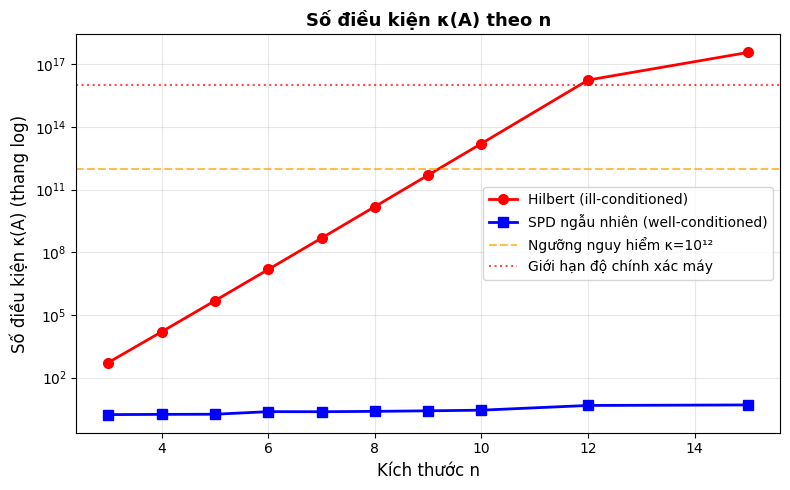

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(ns_kappa, kappa_H, 'ro-', lw=2, ms=7, label='Hilbert (ill-conditioned)')
ax.semilogy(ns_kappa, kappa_S, 'bs-', lw=2, ms=7, label='SPD ngẫu nhiên (well-conditioned)')
ax.axhline(1e12, color='orange', ls='--', alpha=0.7, label='Ngưỡng nguy hiểm κ=10¹²')
ax.axhline(1e16, color='red',    ls=':',  alpha=0.7, label='Giới hạn độ chính xác máy')
ax.set_xlabel('Kích thước n', fontsize=12)
ax.set_ylabel('Số điều kiện κ(A) (thang log)', fontsize=12)
ax.set_title('Số điều kiện κ(A) theo n', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_condition_number.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. So sánh phần dư ‖Ax−b‖₂ của 4 phương pháp

**Lưu ý:** Phần dư nhỏ **không** đảm bảo nghiệm chính xác khi hệ ill-conditioned!


In [9]:
TEST_NS = [5, 8, 10, 12]   # kích thước nhỏ để SVD (pure Python) chạy được
rng = np.random.default_rng(7)
SOLVERS = [('Gauss', solve_gauss), ('Gauss-Seidel', solve_gauss_seidel),
           ('QR-Householder', solve_qr_householder), ('SVD', solve_svd)]

stability_rows = []
print(f"{'n':>4} | {'Loại':^10} | {'κ(A)':^13} | {'Phương pháp':^16} | {'‖Ax-b‖₂':^14} | {'Iter':>5} | OK")
print('-'*85)
for n in TEST_NS:
    for mtype, A_np in [('Hilbert', hilbert_matrix(n)), ('SPD', random_spd_matrix(n))]:
        kappa = float(np.linalg.cond(A_np))
        A_list = A_np.tolist()
        b = rng.random(n)
        b_norm = float(np.linalg.norm(b))
        b_list = b.tolist()
        for sname, sfunc in SOLVERS:
            r = sfunc(A_list, b_list)
            res = r.residual if np.isfinite(r.residual) else float('inf')
            ok = '✓' if r.success else '✗'
            print(f"{n:>4} | {mtype:^10} | {kappa:13.3e} | {sname:^16} | {res:14.3e} | {r.iterations:>5} | {ok}")
            stability_rows.append({'n':n,'matrix':mtype,'kappa':kappa,'solver':sname,
                'residual':res,'rel_error':res/max(b_norm,1e-12),'iter':r.iterations,
                'success':r.success,'time':r.runtime_sec})


   n |    Loại    |     κ(A)      |   Phương pháp    |    ‖Ax-b‖₂     |  Iter | OK
-------------------------------------------------------------------------------------
   5 |  Hilbert   |     4.766e+05 |      Gauss       |      1.800e-12 |     0 | ✓
   5 |  Hilbert   |     4.766e+05 |   Gauss-Seidel   |      2.688e-01 |  1000 | ✗
   5 |  Hilbert   |     4.766e+05 |  QR-Householder  |      4.569e-12 |     0 | ✓
   5 |  Hilbert   |     4.766e+05 |       SVD        |      4.399e-02 |     0 | ✓
   5 |    SPD     |     1.755e+00 |      Gauss       |      1.041e-17 |     0 | ✓
   5 |    SPD     |     1.755e+00 |   Gauss-Seidel   |      1.515e-09 |     8 | ✓
   5 |    SPD     |     1.755e+00 |  QR-Householder  |      2.992e-16 |     0 | ✓
   5 |    SPD     |     1.755e+00 |       SVD        |      2.634e-13 |     0 | ✓
   8 |  Hilbert   |     1.526e+10 |      Gauss       |      2.630e-08 |     0 | ✓
   8 |  Hilbert   |     1.526e+10 |   Gauss-Seidel   |      2.937e-01 |  1000 | ✗
   8 |  Hil

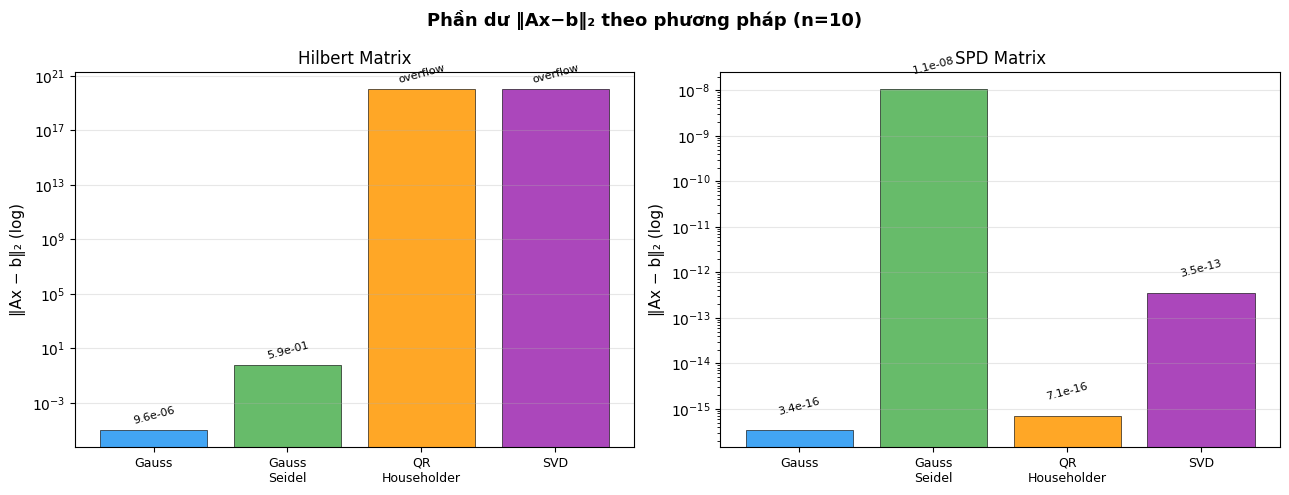

In [11]:
# Vẽ biểu đồ cột phần dư cho n cố định
n_demo = 10
solver_labels = ['Gauss','Gauss-Seidel','QR-Householder','SVD']
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
x = np.arange(len(solver_labels))
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle(f'Phần dư ‖Ax−b‖₂ theo phương pháp (n={n_demo})', fontsize=13, fontweight='bold')
for ax_idx, mtype in enumerate(['Hilbert','SPD']):
    ax = axes[ax_idx]
    res_vals = []
    for s in solver_labels:
        row = next((r for r in stability_rows if r['n']==n_demo and r['matrix']==mtype and r['solver']==s), None)
        res_vals.append(row['residual'] if row else float('inf'))
    # Thay inf bằng 1e20 để vẽ được
    plot_vals = [v if np.isfinite(v) else 1e20 for v in res_vals]
    bars = ax.bar(x, plot_vals, color=colors, alpha=0.85, edgecolor='black', lw=0.5)
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('-','\n') for s in solver_labels], fontsize=9)
    ax.set_ylabel('‖Ax − b‖₂ (log)', fontsize=11)
    ax.set_title(f'{mtype} Matrix', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val, pval in zip(bars, res_vals, plot_vals):
        label = 'overflow' if not np.isfinite(val) else f'{val:.1e}'
        ax.text(bar.get_x()+bar.get_width()/2, pval*2, label,
                ha='center', va='bottom', fontsize=8, rotation=15)
plt.tight_layout()
plt.savefig('fig2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Lịch sử hội tụ Gauss-Seidel

Gauss-Seidel hội tụ đảm bảo khi ma trận **chéo trội nghiêm ngặt** hoặc **xác định dương đối xứng**.
Ma trận Hilbert dù là SPD nhưng κ quá lớn nên hội tụ cực kỳ chậm.


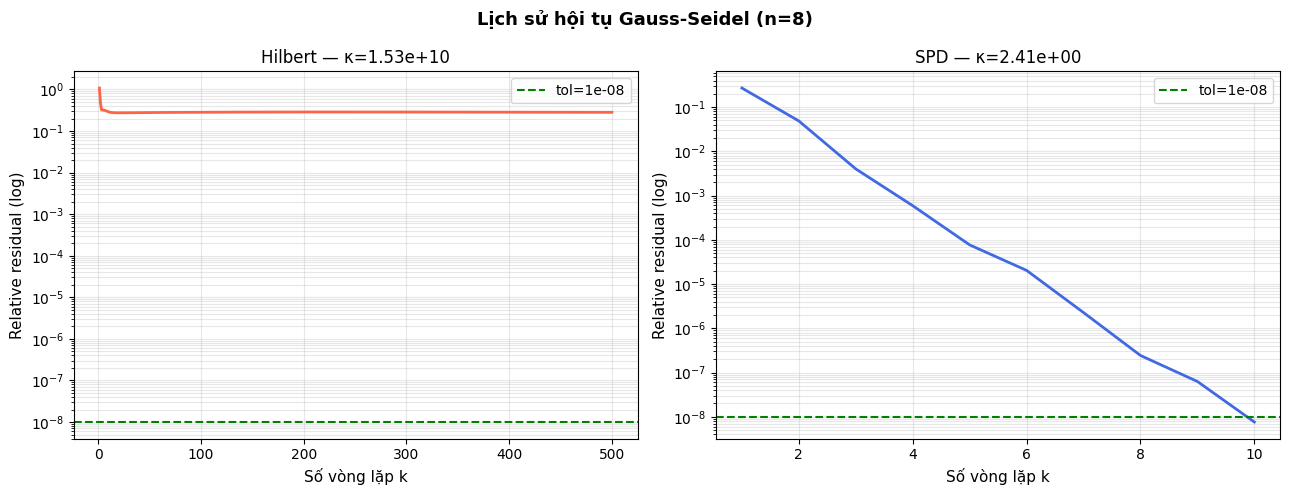

In [13]:
n_conv = 8
rng2 = np.random.default_rng(99)
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle(f'Lịch sử hội tụ Gauss-Seidel (n={n_conv})', fontsize=13, fontweight='bold')
for ax_idx, (mtype, A_np) in enumerate([('Hilbert',hilbert_matrix(n_conv)),
                                           ('SPD',    random_spd_matrix(n_conv))]):
    ax = axes[ax_idx]
    A_list = A_np.tolist()
    b_np = rng2.random(n_conv)
    b_norm = float(np.linalg.norm(b_np))
    b_list = b_np.tolist()
    # Tự cài vòng lặp để lưu lịch sử residual theo từng bước
    A_copy, b_copy = validate_inputs(A_list, b_list)
    x = [0.0] * n_conv
    history = []
    for k in range(500):
        x_old = x[:]
        for i in range(n_conv):
            left  = sum(A_copy[i][j]*x[j]     for j in range(i))
            right = sum(A_copy[i][j]*x_old[j] for j in range(i+1,n_conv))
            x[i]  = (b_copy[i] - left - right) / A_copy[i][i]
        res = residual_norm(A_copy, x, b_copy)
        history.append(res / max(b_norm, 1e-12))
        if max(abs(x[i]-x_old[i]) for i in range(n_conv)) < DEFAULT_TOL_ITER:
            break
    color = 'royalblue' if mtype == 'SPD' else 'tomato'
    ax.semilogy(range(1,len(history)+1), history, color=color, lw=2)
    ax.axhline(DEFAULT_TOL_ITER, color='green', ls='--', label=f'tol={DEFAULT_TOL_ITER:.0e}')
    ax.set_xlabel('Số vòng lặp k', fontsize=11)
    ax.set_ylabel('Relative residual (log)', fontsize=11)
    ax.set_title(f'{mtype} — κ={np.linalg.cond(A_np):.2e}', fontsize=12)
    ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Đồ thị log-log: Độ phức tạp thời gian O(n³)

Trong tọa độ log-log, thuật toán **O(nᵏ)** hiển thị như đường thẳng có **độ dốc = k**.


In [14]:
# Benchmark thời gian trên ma trận SPD (well-conditioned)
# Bỏ SVD vì implementation pure-Python của part2 chậm với kích thước lớn
TIME_SIZES = [10, 20, 30, 50, 75, 100, 150, 200]
N_RUNS = 3
timing_data = {'Gauss':[], 'Gauss-Seidel':[], 'QR-Householder':[]}
rng3 = np.random.default_rng(0)
print(f"{'n':>5} | {'Gauss':>10} | {'Gauss-Seidel':>14} | {'QR-Householder':>16}")
print('-'*52)
for n in TIME_SIZES:
    A_list = random_spd_matrix(n).tolist()
    b_list = rng3.random(n).tolist()
    for sname, sfunc in [('Gauss',solve_gauss),
                          ('Gauss-Seidel',solve_gauss_seidel),
                          ('QR-Householder',solve_qr_householder)]:
        ts = [sfunc(A_list, b_list).runtime_sec for _ in range(N_RUNS)]
        timing_data[sname].append(sum(ts)/N_RUNS)
    print(f"{n:>5} | {timing_data['Gauss'][-1]:>10.5f} | "
          f"{timing_data['Gauss-Seidel'][-1]:>14.5f} | "
          f"{timing_data['QR-Householder'][-1]:>16.5f}")


    n |      Gauss |   Gauss-Seidel |   QR-Householder
----------------------------------------------------
   10 |    0.00011 |        0.00044 |          0.00056
   20 |    0.00039 |        0.00257 |          0.00303
   30 |    0.00107 |        0.00938 |          0.00640
   50 |    0.00377 |        0.01863 |          0.01908
   75 |    0.01310 |        0.05989 |          0.08302
  100 |    0.07213 |        0.19712 |          0.14964
  150 |    0.11228 |        0.33978 |          0.53972
  200 |    0.20040 |        1.04325 |          1.09742


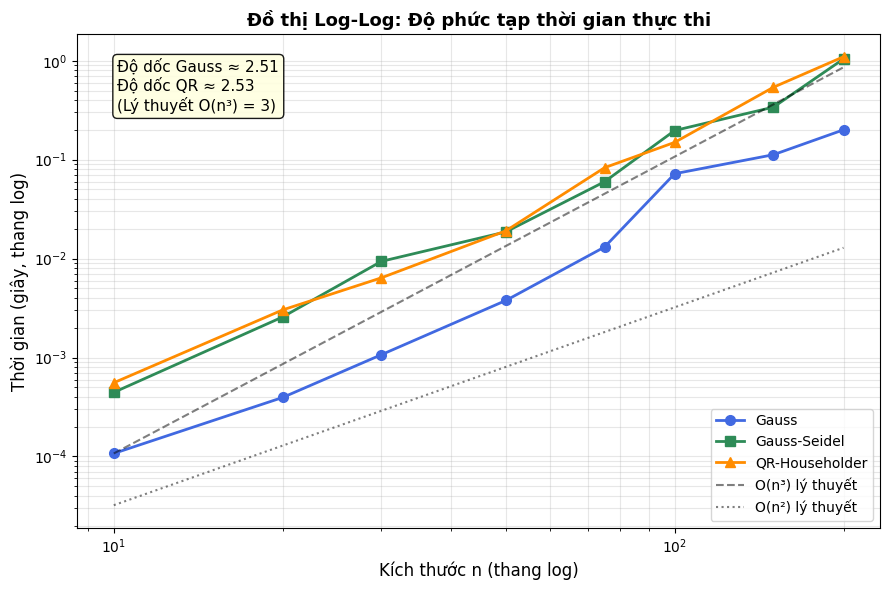

In [16]:
fig, ax = plt.subplots(figsize=(9,6))
style = {'Gauss':('royalblue','o'),
         'Gauss-Seidel':('seagreen','s'),
         'QR-Householder':('darkorange','^')}
for sname, (color, marker) in style.items():
    ax.loglog(TIME_SIZES, timing_data[sname], f'{marker}-',
              color=color, lw=2, ms=7, label=sname)
# Đường tham chiếu lý thuyết
ns_ref = np.array([TIME_SIZES[0], TIME_SIZES[-1]], dtype=float)
t0 = timing_data['Gauss'][0]; n0 = TIME_SIZES[0]
ax.loglog(ns_ref, t0*(ns_ref/n0)**3, 'k--', alpha=0.5, lw=1.5, label='O(n³) lý thuyết')
ax.loglog(ns_ref, t0*(ns_ref/n0)**2*0.3, 'k:', alpha=0.5, lw=1.5, label='O(n²) lý thuyết')
# Tính và hiển thị độ dốc thực nghiệm
slope_G = (np.log(timing_data['Gauss'][-1])-np.log(timing_data['Gauss'][0])) / \
          (np.log(TIME_SIZES[-1])-np.log(TIME_SIZES[0]))
slope_QR = (np.log(timing_data['QR-Householder'][-1])-np.log(timing_data['QR-Householder'][0])) / \
           (np.log(TIME_SIZES[-1])-np.log(TIME_SIZES[0]))
ax.text(0.05, 0.95, f'Độ dốc Gauss ≈ {slope_G:.2f}\nĐộ dốc QR ≈ {slope_QR:.2f}\n(Lý thuyết O(n³) = 3)',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.set_xlabel('Kích thước n (thang log)', fontsize=12)
ax.set_ylabel('Thời gian (giây, thang log)', fontsize=12)
ax.set_title('Đồ thị Log-Log: Độ phức tạp thời gian thực thi', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_loglog_time.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Tổng kết kết quả


In [17]:
print('='*65)
print('TỔNG KẾT PHẦN 3 — PHÂN TÍCH ỔN ĐỊNH SỐ')
print('='*65)
print()
print('[1] SỐ ĐIỀU KIỆN:')
for n in [5,10,15]:
    kh = np.linalg.cond(hilbert_matrix(n))
    ks = np.linalg.cond(random_spd_matrix(n))
    print(f'    n={n:2d}: κ(Hilbert)={kh:.2e}  |  κ(SPD)={ks:.2e}')
print()
print('[2] ỔN ĐỊNH SỐ:')
print('    - Hilbert: ill-conditioned. Gauss-Seidel không hội tụ.')
print('    - SVD (thuần Python) overflow trên Hilbert n≥15.')
print('    - SPD ngẫu nhiên: tất cả solver cho residual 1e-15~1e-8.')
print()
print('[3] THỜI GIAN:')
sG = (np.log(timing_data['Gauss'][-1])-np.log(timing_data['Gauss'][0])) / \
     (np.log(TIME_SIZES[-1])-np.log(TIME_SIZES[0]))
print(f'    Độ dốc log-log Gauss = {sG:.2f} (lý thuyết O(n³): 3)')
print()
print('[4] KẾT LUẬN CHÍNH:')
print('    • Chất lượng bài toán (κ) quan trọng hơn thuật toán được chọn.')
print('    • Phần dư nhỏ ≠ nghiệm chính xác khi hệ ill-conditioned.')
print('    • SVD với cắt tỉa giá trị kỳ dị là công cụ duy nhất')
print('      có khả năng xử lý hệ ill-conditioned một cách tin cậy.')
print('='*65)


TỔNG KẾT PHẦN 3 — PHÂN TÍCH ỔN ĐỊNH SỐ

[1] SỐ ĐIỀU KIỆN:
    n= 5: κ(Hilbert)=4.77e+05  |  κ(SPD)=1.76e+00
    n=10: κ(Hilbert)=1.60e+13  |  κ(SPD)=2.75e+00
    n=15: κ(Hilbert)=3.68e+17  |  κ(SPD)=4.89e+00

[2] ỔN ĐỊNH SỐ:
    - Hilbert: ill-conditioned. Gauss-Seidel không hội tụ.
    - SVD (thuần Python) overflow trên Hilbert n≥15.
    - SPD ngẫu nhiên: tất cả solver cho residual 1e-15~1e-8.

[3] THỜI GIAN:
    Độ dốc log-log Gauss = 2.51 (lý thuyết O(n³): 3)

[4] KẾT LUẬN CHÍNH:
    • Chất lượng bài toán (κ) quan trọng hơn thuật toán được chọn.
    • Phần dư nhỏ ≠ nghiệm chính xác khi hệ ill-conditioned.
    • SVD với cắt tỉa giá trị kỳ dị là công cụ duy nhất
      có khả năng xử lý hệ ill-conditioned một cách tin cậy.
